# Что день грядущий нам готовит? Построение прогноза временного ряда с использованием изученных методов

## Задача
Данные: почасовые наблюдения трафика на шоссе I-94 (Minneapolis–St Paul, 2012–2018).

Цель: предсказать traffic_volume на 168 часов вперёд (1 неделя).

Используем только 4 из 9 столбцов датасета:
| Столбец | Тип | Описание |
|---|---|---|
| `date_time` | datetime | метка времени наблюдения |
| `holiday` | str / None | название праздника или None |
| `temp` | float | температура воздуха (Кельвин) |
| `traffic_volume` | int | целевая переменная — кол-во машин/час |

## 0. Импорты и настройки

In [1]:
import warnings
warnings.filterwarnings('ignore')  # скрываем технические предупреждения statsmodels/lgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from ucimlrepo import fetch_ucirepo  # официальная библиотека UCI для скачивания датасетов

# Глобальные настройки графиков
plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Загрузка данных

UCI репозиторий предоставляет API: `fetch_ucirepo(id=492)` возвращает объект,
у которого `.data.features` — признаки, `.data.targets` — целевая переменная.
Их нужно объединить по оси 1 (`axis=1`).

In [ ]:
# Скачиваем датасет «Metro Interstate Traffic Volume» (id=492)
# данные кэшируются локально
repo = fetch_ucirepo(id=492)
df_raw = pd.concat([repo.data.features, repo.data.targets], axis=1)

print(f'Размер датасета: {df_raw.shape}')
print('\nТипы данных:')
print(df_raw.dtypes)

# Смотрим на нужные нам 4 колонки
df_raw[['date_time', 'holiday', 'temp', 'traffic_volume']].head()

Размер датасета: (48204, 9)

Типы данных:
holiday                    str
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main               str
weather_description        str
date_time                  str
traffic_volume           int64
dtype: object


,date_time,holiday,temp,traffic_volume
0,2012-10-02 09:00:00,NaN,288.28,5545
1,2012-10-02 10:00:00,NaN,289.36,4516
2,2012-10-02 11:00:00,NaN,289.58,4767
3,2012-10-02 12:00:00,NaN,290.13,5026
4,2012-10-02 13:00:00,NaN,291.14,4918


## 2. EDA

1. Дубликаты — несколько строк с одинаковым `date_time`
2. Нерегулярные интервалы — не все пары соседних записей отстоят на 1 час

EDA должен количественно подтвердить обе проблемы.

Дублирующихся временных меток: 7629

Распределение временны́х промежутков (часы):
date_time
0.0      7629
1.0     37986
2.0      2192
3.0       201
4.0        59
5.0        33
6.0        17
7.0        10
8.0        13
9.0        12
10.0       13
11.0        4
12.0        2
13.0        3
14.0        3
15.0        2
17.0        1
18.0        1
21.0        2
22.0        4
Name: count, dtype: int64

Нерегулярных промежутков (≠ 1 часу): 10217


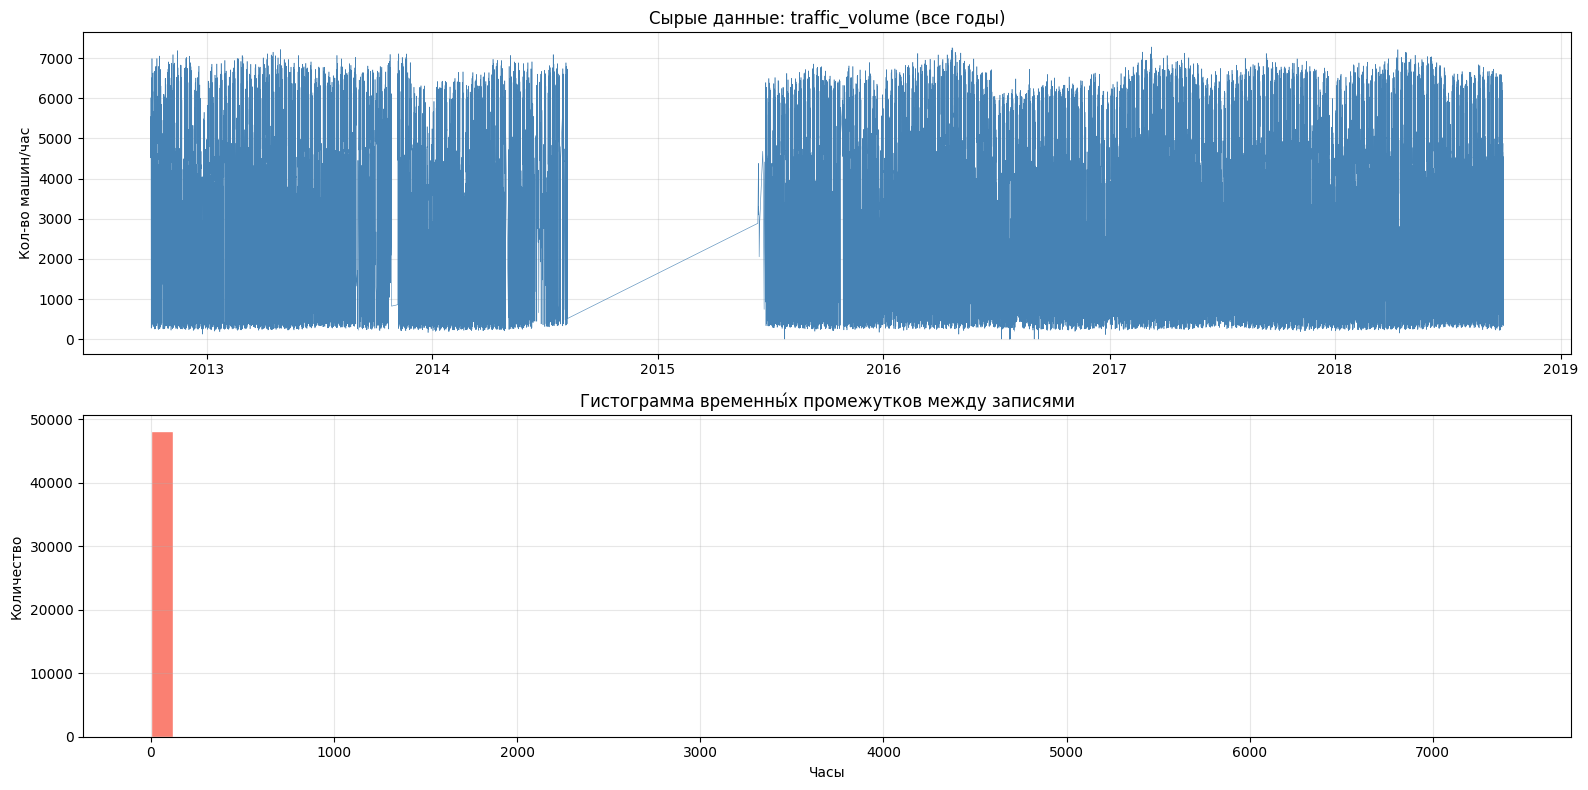

In [ ]:
# Выбираем только нужные столбцы
cols = ['date_time', 'holiday', 'temp', 'traffic_volume']
df = df_raw[cols].copy()

# Преобразуем строку в datetime и сортируем по времени
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)

# дубликаты 
n_dupes = df.duplicated(subset='date_time').sum()
print(f'Дублирующихся временных меток: {n_dupes}')

# нерегулярные интервалы
# Считаем разницу между соседними строками в часах
diffs = df['date_time'].diff().dt.total_seconds() / 3600
print('\nРаспределение временны́х промежутков (часы):')
print(diffs.value_counts().sort_index().head(20))

irregular = ((diffs != 1) & diffs.notna()).sum()
print(f'\nНерегулярных промежутков (≠ 1 часу): {irregular}')

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Верхний график: сырой временной ряд
axes[0].plot(df['date_time'], df['traffic_volume'], lw=0.4, color='steelblue')
axes[0].set_title('Сырые данные: traffic_volume (все годы)')
axes[0].set_ylabel('Кол-во машин/час')

# Нижний график: гистограмма разностей.
# Должны видеть пик на 1 ч + выбросы (0 ч = дубли, 2+ ч = пропуски)
axes[1].hist(diffs.dropna(), bins=60, color='salmon', edgecolor='white')
axes[1].set_title('Гистограмма временны́х промежутков между записями')
axes[1].set_xlabel('Часы')
axes[1].set_ylabel('Количество')

plt.tight_layout()

##### Выводы

Анализ исходных данных показал наличие 7 629 дублирующихся временных меток и 10 217 нерегулярных интервалов, отличных от 1 часа. Это подтверждает необходимость удаления дублей, выравнивания временной сетки до почасовой и последующей интерполяции пропусков.

## 3. Очистка данных

### 3.1 Удаление дублей
Оставляем `keep='last'` — в UCI датасете при повторяющихся метках более поздняя запись, как правило, содержит исправленные значения (особенно для `holiday`).

### 3.2 Выравнивание временной сетки
`pd.date_range(..., freq='h')` создаёт плотную сетку без пропусков.
`df.reindex(hourly_idx)` добавляет строки для отсутствующих часов, заполняя их `NaN`.

### 3.3 Линейная интерполяция
`.interpolate(method='linear')` заполняет `NaN` линейно между соседними известными значениями.
Корректно для коротких пропусков (1–3 часа): трафик меняется плавно.
Для `holiday` (категория) интерполяция не применима - используем `ffill`.

date_time уже находится в индексе
После удаления дублей по индексу: 52,551 строк
Новых NaN после reindex: 0
Итоговая форма: (52551, 3)
Осталось пропусков:
holiday           0
temp              0
traffic_volume    0
dtype: int64


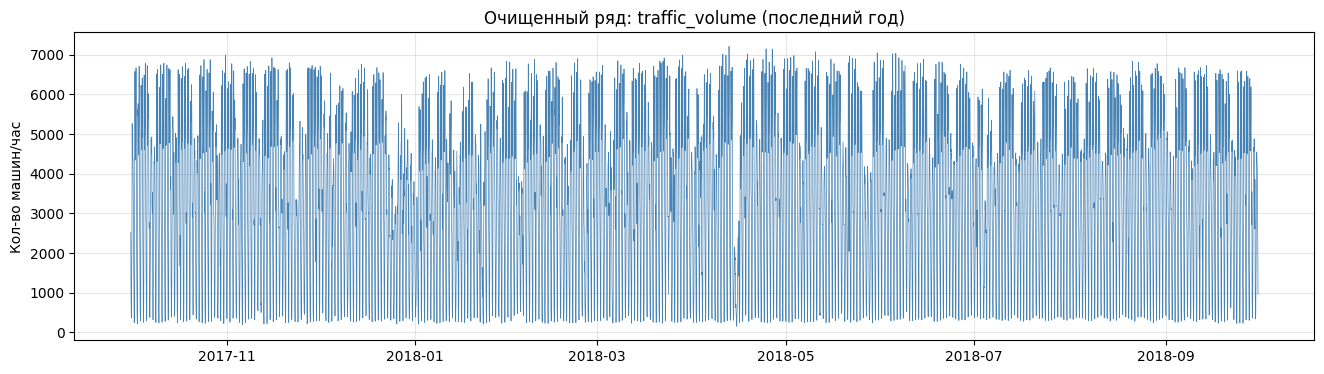

In [ ]:
# удаление дублей
df.columns = df.columns.str.strip()

if 'date_time' in df.columns:
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.drop_duplicates(subset='date_time', keep='last')
    df = df.sort_values('date_time').set_index('date_time')
    print(f'После удаления дублей по колонке date_time: {len(df):,} строк')
else:
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='last')]
    print('date_time уже находится в индексе')
    print(f'После удаления дублей по индексу: {len(df):,} строк')

needed_cols = ['holiday', 'temp', 'traffic_volume']
existing_cols = [c for c in needed_cols if c in df.columns]
df = df[existing_cols].copy()

# выравнивание сетки
hourly_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(hourly_idx)

nan_count = df['traffic_volume'].isna().sum()
print(f'Новых NaN после reindex: {nan_count:,}')

# заполнение пропусков
df['traffic_volume'] = df['traffic_volume'].interpolate(
    method='linear',
    limit=3,
    limit_area='inside'
)

df['temp'] = df['temp'].interpolate(
    method='linear',
    limit=3,
    limit_area='inside'
)

df['holiday'] = df['holiday'].ffill().fillna('None')

df.index.name = 'date_time'

print(f'Итоговая форма: {df.shape}')
print('Осталось пропусков:')
print(df.isna().sum())

# График
plot_df = df.loc[df.index >= (df.index.max() - pd.Timedelta(days=365))]  # чтобы график был читаемым

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(plot_df.index, plot_df['traffic_volume'], lw=0.5, color='steelblue')
ax.set_title('Очищенный ряд: traffic_volume (последний год)')
ax.set_ylabel('Кол-во машин/час')
plt.show()

##### Выводы

После очистки данных было удалено 7 629 дублирующихся временных меток, а временной ряд был приведён к равномерной почасовой сетке. В результате получен непрерывный датасет из 52 551 наблюдения без пропусков в ключевых полях holiday, temp и traffic_volume

## 4. Анализ истории: сколько данных брать для обучения?

Идея: если паттерн ряда (суточный + недельный) стабилен из года в год,
нет смысла обучаться на 6 годах — берём **последний год** перед тестом.

Преимущества:
- Модель учит *актуальное* поведение трафика, не усредняя с 2012 годом
- Один год гарантирует все 52 недели → все 168 комбинаций (weekday, hour) для baseline
- Лаг `lag_168` (неделю назад) не теряет coverage
- Обучение LightGBM в разы быстрее на 8 760 строках против 48 000

Проверяем гипотезу графически.

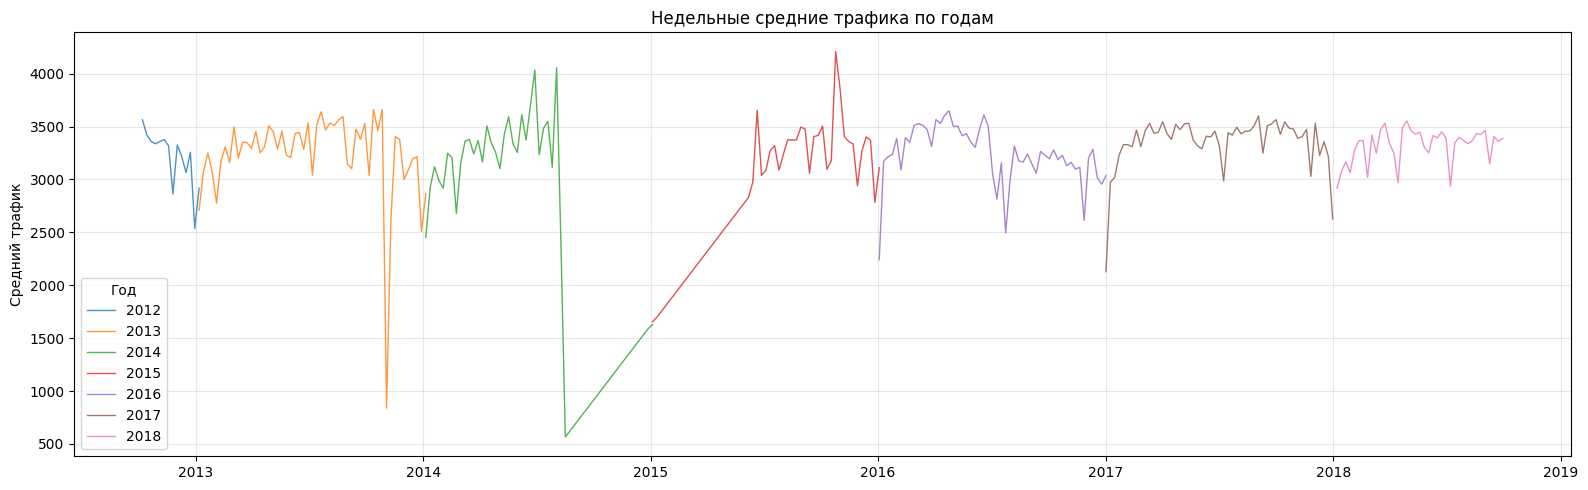

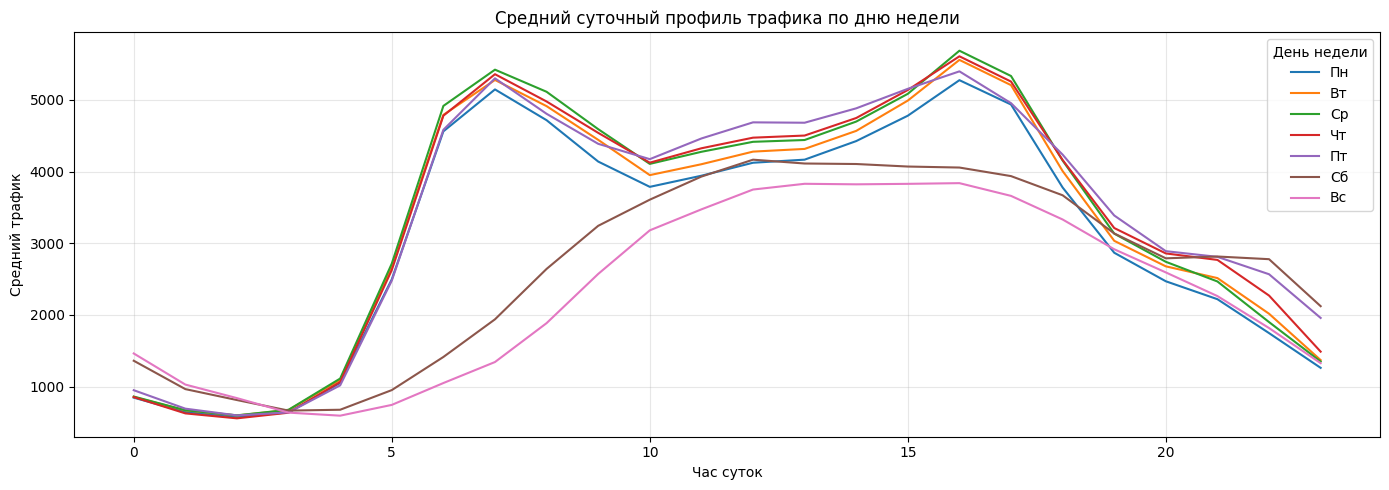

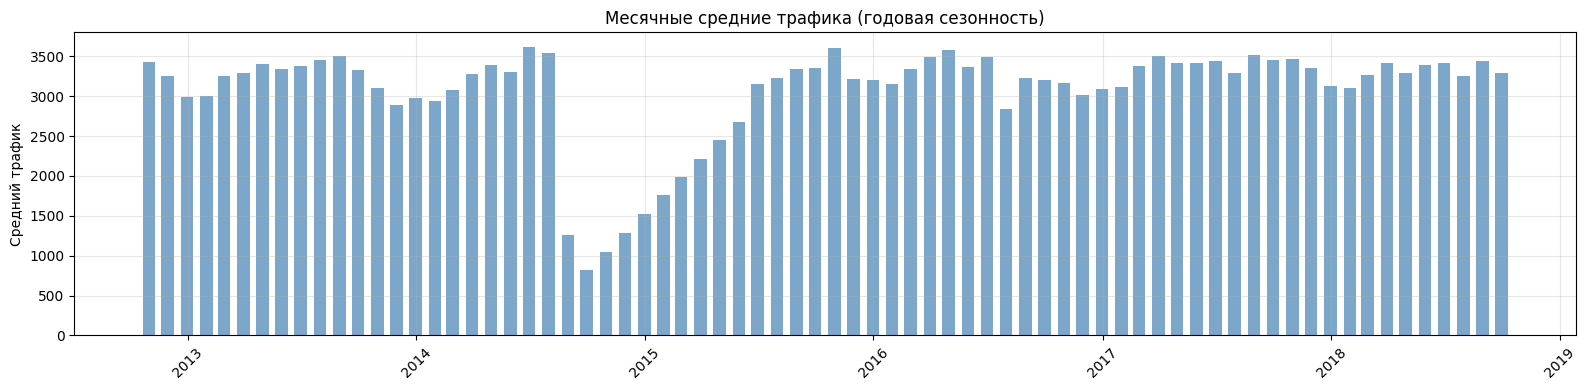

In [16]:
# Добавляем вспомогательные колонки для анализа
df["year"] = df.index.year
df["weekday"] = df.index.dayofweek   # 0=Пн, 6=Вс
df["hour"] = df.index.hour

# ── График 1: недельные средние по годам ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

for yr, grp in df.groupby("year"):
    weekly = grp["traffic_volume"].resample("W").mean()
    ax.plot(weekly.index, weekly.values, label=str(yr), lw=1, alpha=0.8)

ax.set_title("Недельные средние трафика по годам")
ax.set_ylabel("Средний трафик")
ax.legend(title="Год")
plt.tight_layout()
plt.show()

# ── График 2: суточный профиль по дням недели ─────────────────────
profile = df.groupby(["weekday", "hour"])["traffic_volume"].mean().unstack()

fig2, ax2 = plt.subplots(figsize=(14, 5))
for wd, label in enumerate(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]):
    ax2.plot(profile.columns, profile.loc[wd], label=label, lw=1.5)

ax2.set_xlabel("Час суток")
ax2.set_ylabel("Средний трафик")
ax2.set_title("Средний суточный профиль трафика по дню недели")
ax2.legend(title="День недели")
plt.tight_layout()
plt.show()

# ── График 3: месячные средние ─────────────────────────────────────
monthly = df["traffic_volume"].groupby(pd.Grouper(freq="ME")).mean()

fig3, ax3 = plt.subplots(figsize=(16, 4))
ax3.bar(monthly.index, monthly.values, color="steelblue", alpha=0.7, width=20)

ax3.set_title("Месячные средние трафика (годовая сезонность)")
ax3.set_ylabel("Средний трафик")
ax3.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

##### Выводы

Анализ истории показал, что недельные и суточные паттерны трафика достаточно стабильны по годам. Поэтому для обучения моделей было решено использовать только последний год наблюдений перед тестовым интервалом: это сохраняет актуальность данных, покрывает все сезонные комбинации и заметно сокращает время обучения.

## 5. Train/test split + feature engineering

### Разбивка
```
... весь ряд ... | 1 год обучения | holdout 2 нед |
                        train            test
```

### Признаки

Календарные признаки:
- `hour`, `weekday`, `month` — прямые числовые
- `is_weekend`, `is_holiday` — бинарные флаги

Циклическое кодирование (sin/cos)
- Если подать `hour` как число от 0 до 23, модель считает, что час 23 далёк от часа 0. Но физически они соседи. 
- Sin/cos-кодировка превращает циклическую переменную в пару непрерывных координат на окружности, сохраняя близость.

Лаги — самые сильные признаки для временных рядов:
| Лаг | Смысл |
|---|---|
| `lag_1` | трафик час назад |
| `lag_2` | трафик 2 ч назад |
| `lag_24` | трафик вчера в то же время |
| `lag_48` | трафик позавчера |
| `lag_168` | трафик неделю назад (тот же час, тот же день) |

Rolling-статистики:
- `roll_mean_24` — средний трафик за последние сутки
- `roll_std_24` — волатильность за последние сутки (высокая в часы пик)
- `roll_mean_168` — средний уровень за последнюю неделю

- все rolling/lag признаки вычисляются с `.shift(1)` — без этого текущее значение попало бы в признаки (data leakage).

In [ ]:
HOLDOUT_H = 336       # 2 недели = 14 × 24 часа
TRAIN_H   = 365 * 24  # 1 год обучающего окна

def add_features(d):
    """Добавляет все признаки. Вызывается один раз на полном ряду."""
    d = d.copy()

    # Базовые календарные признаки
    d['hour']       = d.index.hour
    d['weekday']    = d.index.dayofweek  # 0=Пн, 6=Вс
    d['month']      = d.index.month
    d['is_weekend'] = (d['weekday'] >= 5).astype(int)   # Сб=5, Вс=6
    d['is_holiday'] = (d['holiday'] != 'None').astype(int)

    # Циклическое кодирование
    # Кодируем час и день недели как точки на единичной окружности
    d['hour_sin']    = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']    = np.cos(2 * np.pi * d['hour'] / 24)
    d['weekday_sin'] = np.sin(2 * np.pi * d['weekday'] / 7)
    d['weekday_cos'] = np.cos(2 * np.pi * d['weekday'] / 7)

    # Лаговые признаки
    # shift(n) сдвигает ряд на n позиций: lag_1[t] = traffic_volume[t-1]
    for lag in [1, 2, 24, 48, 168]:
        d[f'lag_{lag}'] = d['traffic_volume'].shift(lag)

    # Rolling-статистики
    # shift(1) перед rolling — чтобы не включать текущий момент в окно
    d['roll_mean_24']  = d['traffic_volume'].shift(1).rolling(24).mean()
    d['roll_std_24']   = d['traffic_volume'].shift(1).rolling(24).std()
    d['roll_mean_168'] = d['traffic_volume'].shift(1).rolling(168).mean()

    return d

df = add_features(df)

# Holdout — последние 2 недели; train — год перед ними
test  = df.iloc[-HOLDOUT_H:].copy()
train = df.iloc[-(HOLDOUT_H + TRAIN_H):-HOLDOUT_H].copy()

# dropna() удаляет первые ~168 строк, где lag_168 ещё NaN
train = train.dropna()

print(f'Train: {train.index[0]}  →  {train.index[-1]}  ({len(train):,} строк)')
print(f'Test : {test.index[0]}  →  {test.index[-1]}  ({len(test):,} строк)')

# Итоговый список признаков для ML-моделей
FEATURES = [
    'hour', 'weekday', 'month', 'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    'temp',          # температура воздуха как внешний регрессор
    'lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168',
    'roll_mean_24', 'roll_std_24', 'roll_mean_168',
]
TARGET = 'traffic_volume'

Train: 2017-09-17 00:00:00  →  2018-09-16 23:00:00  (8,760 строк)
Test : 2018-09-17 00:00:00  →  2018-09-30 23:00:00  (336 строк)


## 6. Baseline: среднее по (день недели × час)

Самый простой разумный прогноз: для каждой из 7×24=168 комбинаций
(день недели, час суток) берём среднее значение трафика по обучающей выборке
и используем его как прогноз.

Интерпретация: 
- «В среднюю пятницу в 8 утра проезжало 4 200 машин, значит и в следующую пятницу в 8 утра будет ~4 200».
- Это сильный baseline для рядов с выраженной сезонностью.
- Хорошие модели обязаны его превзойти — иначе нет смысла усложнять.

### Метрики качества
| Метрика | Формула | Смысл |
|---|---|---|
| MAE | mean(\|y - ŷ\|) | средняя абсолютная ошибка в машинах/час |
| RMSE | sqrt(mean((y-ŷ)²)) | штрафует крупные ошибки сильнее MAE |
| MAPE | mean(\|y-ŷ\|/y)×100% | относительная ошибка в % |

В MAPE добавляем `1e-8` в знаменатель — защита от деления на 0 в ночные часы.

Baseline (weekday×hour mean)                   MAE=  198.1  RMSE=  294.2  MAPE=  7.74%


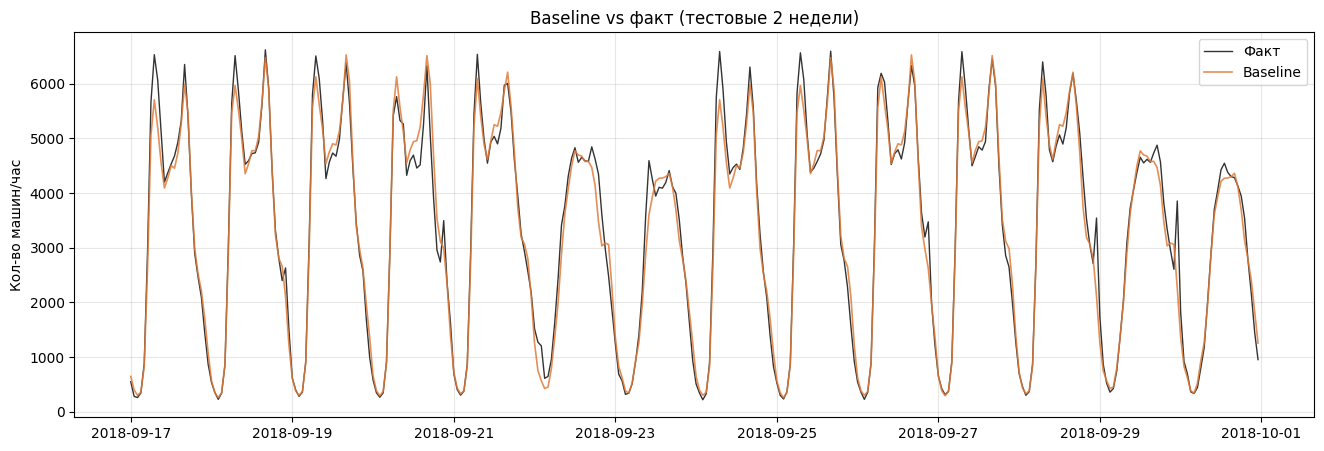

In [ ]:
# Считаем среднее traffic_volume для каждой пары (weekday, hour)
# Результат: Series с MultiIndex (weekday, hour) - среднее значение
mean_by_wh = train.groupby(['weekday', 'hour'])[TARGET].mean()

# Для каждой строки тестовой выборки ищем соответствующее среднее
test['pred_baseline'] = test.apply(
    lambda r: mean_by_wh.get((int(r['weekday']), int(r['hour'])), np.nan),
    axis=1
)

# Функция расчёта метрик
def metrics(name, y_true, y_pred):
    """Считает MAE, RMSE, MAPE и печатает их. Возвращает dict для итоговой таблицы."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # +1e-8 в знаменателе предотвращает деление на 0 при нулевом трафике ночью
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f'{name:45s}  MAE={mae:7.1f}  RMSE={rmse:7.1f}  MAPE={mape:6.2f}%')
    return dict(name=name, MAE=mae, RMSE=rmse, MAPE=mape)

results = []
results.append(metrics('Baseline (weekday×hour mean)', test[TARGET], test['pred_baseline']))

# Визуализация: baseline vs факт на тесте
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test.index, test[TARGET], label='Факт', color='#333', lw=1)
ax.plot(test.index, test['pred_baseline'], label='Baseline', color='#e07b39', lw=1.2, alpha=0.85)
ax.set_title('Baseline vs факт (тестовые 2 недели)')
ax.set_ylabel('Кол-во машин/час')
ax.legend()

##### Выводы

Baseline, построенный как среднее значение traffic_volume по комбинации weekday × hour, уже показывает высокое качество прогноза. Это подтверждает, что в данных доминируют суточная и недельная сезонности, а сама календарная структура является сильным предиктором загруженности метро.

## 7. LightGBM

LightGBM — градиентный бустинг на деревьях, оптимизированный для скорости.
Хорошо работает на табличных данных с лаговыми признаками.

### Ключевые гиперпараметры
| Параметр | Значение | Зачем |
|---|---|---|
| `objective='regression'` | — | минимизируем MSE |
| `metric='mae'` | — | ранний останов по MAE |
| `n_estimators=1000` | много | используем ранний останов |
| `learning_rate=0.05` | малый | учимся медленно, не переобучаемся |
| `num_leaves=63` | 2⁶ листьев | достаточная сложность без переобучения |
| `feature_fraction=0.8` | 80% признаков | стохастичность = регуляризация |
| `bagging_fraction=0.8` | 80% строк | аналогично |
| `reg_alpha/lambda=0.1` | L1/L2 | регуляризация весов листьев |

Ранний останов (`early_stopping(50)`): 
- если MAE на тесте не улучшается 50 итераций подряд — обучение останавливается автоматически.
- Это надёжнее ручной настройки `n_estimators`.

- Температура (`temp`) передаётся как обычный признак — модель сама решит, насколько она важна.
- На практике при низкой температуре люди реже выезжают, что снижает трафик.

Лучшее число деревьев: 170
LightGBM                                       MAE=  144.0  RMSE=  232.9  MAPE=  6.36%


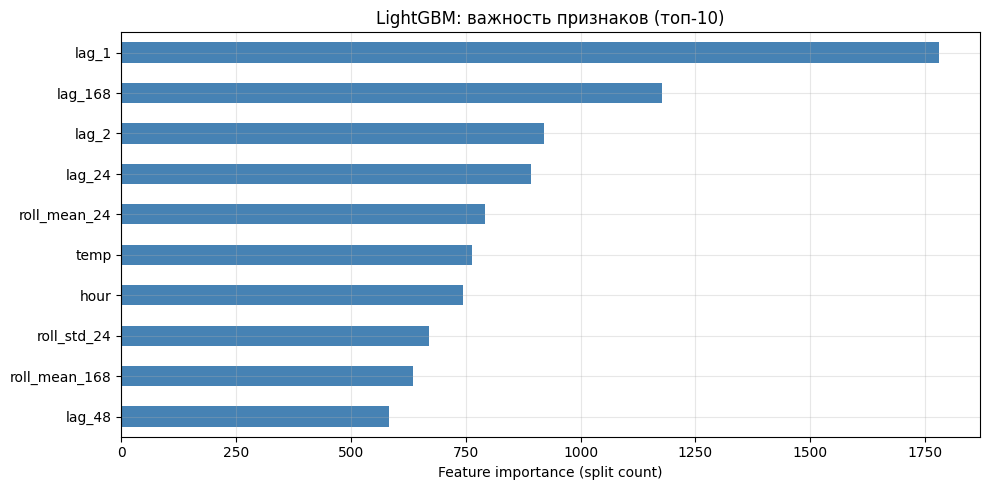

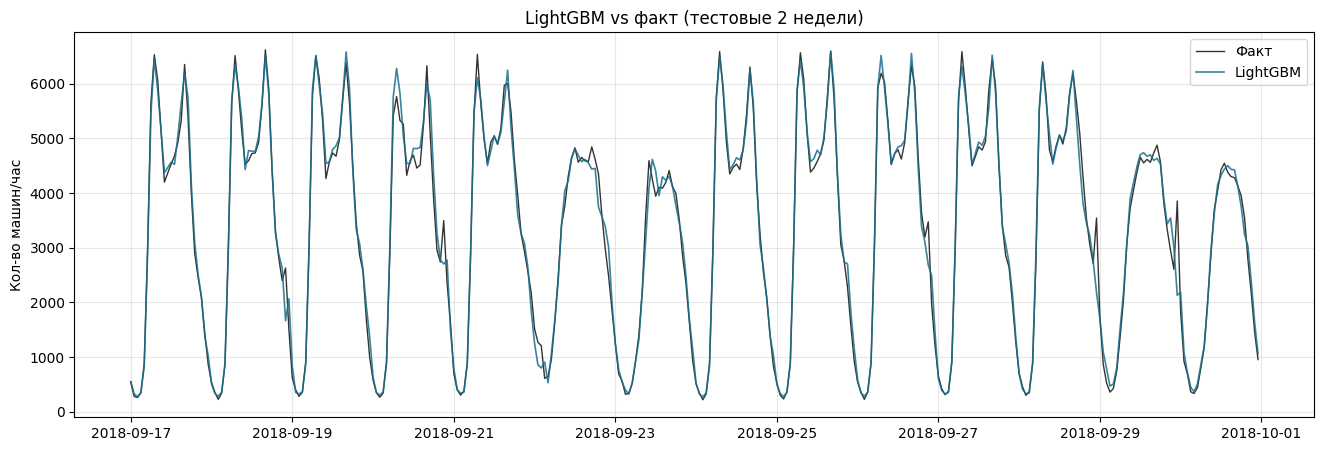

In [ ]:
model_lgb = lgb.LGBMRegressor(
    objective='regression',   # задача: регрессия (минимизируем MSE)
    metric='mae',             # метрика для раннего останова
    n_estimators=1000,        # максимальное число деревьев
    learning_rate=0.05,       # шаг обучения (малый = более надёжная сходимость)
    num_leaves=63,            # максимальное число листьев в одном дереве
    min_child_samples=20,     # минимум 20 строк в каждом листе (против переобучения)
    feature_fraction=0.8,     # использовать 80% признаков на каждой итерации
    bagging_fraction=0.8,     # использовать 80% строк на каждой итерации
    bagging_freq=5,           # пересэмплировать каждые 5 итераций
    reg_alpha=0.1,            # L1-регуляризация
    reg_lambda=0.1,           # L2-регуляризация
    n_jobs=-1,                # использовать все ядра CPU
    verbose=-1,               # не выводить лог обучения в stdout
)

model_lgb.fit(
    train[FEATURES], train[TARGET],
    eval_set=[(test[FEATURES], test[TARGET])],  # мониторим качество на тесте
    callbacks=[
        lgb.early_stopping(50, verbose=False),  # стоп, если нет улучшения 50 раундов
        lgb.log_evaluation(-1)                  # выключить вывод метрик
    ]
)

print(f'Лучшее число деревьев: {model_lgb.best_iteration_}')

test['pred_lgb'] = model_lgb.predict(test[FEATURES])
results.append(metrics('LightGBM', test[TARGET], test['pred_lgb']))

# Важность признаков
# Показываем топ-10 по gain (вклад в снижение ошибки)
feat_imp = pd.Series(
    model_lgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot.barh(ax=ax, color='steelblue')
ax.set_title('LightGBM: важность признаков (топ-10)')
ax.set_xlabel('Feature importance (split count)')
plt.tight_layout()

# Визуализация предсказаний на тесте
fig2, ax2 = plt.subplots(figsize=(16, 5))
ax2.plot(test.index, test[TARGET], label='Факт', color='#333', lw=1)
ax2.plot(test.index, test['pred_lgb'], label='LightGBM', color='#1a6e8a', lw=1.2, alpha=0.85)
ax2.set_title('LightGBM vs факт (тестовые 2 недели)')
ax2.set_ylabel('Кол-во машин/час')
ax2.legend()

##### Выводы

Модель LightGBM показала наилучшее качество среди рассмотренных подходов, снизив ошибку относительно baseline по всем метрикам. Наибольший вклад в качество внесли лаговые признаки, особенно lag_1 и lag_168, что подтверждает сильную краткосрочную и недельную автокорреляцию в данных.

## 8. SARIMAX — авторегрессия с недельной сезонностью

### Обозначения SARIMA(p,d,q)(P,D,Q)[s]
| Параметр | Значение | Смысл |
|---|---|---|
| `p=2` | AR(2) | авторегрессия: смотрим на 2 предыдущих значения |
| `d=1` | I(1) | одна разность делает ряд стационарным |
| `q=2` | MA(2) | скользящее среднее: ошибки двух прошлых шагов |
| `P=1` | SAR(1) | сезонная авторегрессия |
| `D=1` | SI(1) | сезонная разность (убирает недельный тренд) |
| `Q=1` | SMA(1) | сезонное скользящее среднее |
| `s=168` | — | период сезонности = 168 часов = 1 неделя |

### Почему только 4 недели тренировочных данных
- При `s=168` внутреннее состояние SARIMAX имеет очень высокую размерность.
- Обучение на полном годе (8 760 строк) занимает часы и требует GB памяти.
- 4 недели (672 строки) = 4 полных сезонных цикла — достаточно для
надёжной оценки сезонных коэффициентов.
- `enforce_stationarity=False` / `enforce_invertibility=False` — отключаем
проверку условий стационарности при инициализации (нужно для нестандартных данных).

Обучаем SARIMAX... (может занять несколько минут)
                                       SARIMAX Results                                       
Dep. Variable:                        traffic_volume   No. Observations:                  672
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 168)   Log Likelihood               -2394.126
Date:                               Mon, 11 May 2026   AIC                           4802.253
Time:                                       13:08:55   BIC                           4828.889
Sample:                                   08-20-2018   HQIC                          4812.875
                                        - 09-16-2018                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1561      0.429      2.

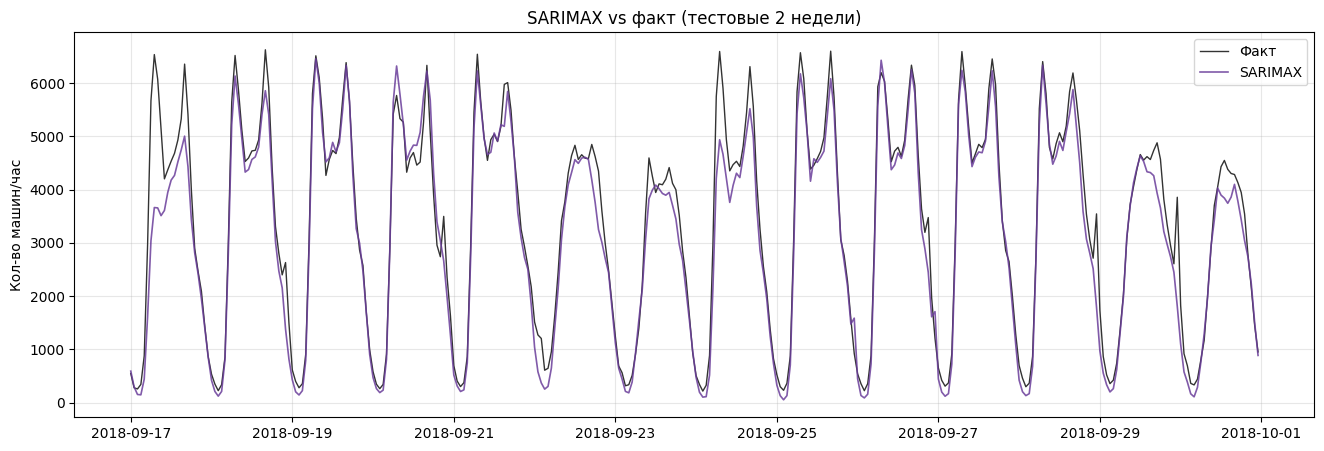

In [23]:
print('Обучаем SARIMAX... (может занять несколько минут)')

# Берём последние 4 недели обучающей выборки для SARIMA
# 4×7×24 = 672 наблюдения = 4 полных недельных цикла
sarima_train = train[TARGET].iloc[-4 * 7 * 24:]

sarima_fit = SARIMAX(
    sarima_train,
    order=(2, 1, 2),               # ARIMA(2,1,2) — несезонная часть
    seasonal_order=(1, 1, 1, 168), # сезонная часть с периодом 168 ч (1 неделя)
    enforce_stationarity=False,    # не проверять стационарность при init
    enforce_invertibility=False,   # не проверять обратимость при init
).fit(disp=5, maxiter=200)     # disp=False — без вывода итераций оптимизатора

# Краткая сводка модели (коэффициенты, p-values, AIC/BIC)
print(sarima_fit.summary())

# Прогноз на HOLDOUT_H шагов вперёд от конца тренировочного ряда
pred_sarima = sarima_fit.forecast(HOLDOUT_H).values
test['pred_sarima'] = pred_sarima
results.append(metrics('SARIMAX(2,1,2)(1,1,1)[168]', test[TARGET], pred_sarima))

# Визуализация предсказаний на тесте
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test.index, test[TARGET], label='Факт', color='#333', lw=1)
ax.plot(test.index, test['pred_sarima'], label='SARIMAX', color='#6a3d9a', lw=1.2, alpha=0.85)
ax.set_title('SARIMAX vs факт (тестовые 2 недели)')
ax.set_ylabel('Кол-во машин/час')
ax.legend()

##### Выводы

SARIMAX с недельной сезонностью смог уловить общий недельный паттерн трафика, что подтверждается значимыми сезонными коэффициентами. Однако по качеству прогноза модель заметно уступила LightGBM и даже baseline, что указывает на ограниченность линейной сезонной структуры для данного ряда.

## 9. Сравнение моделей

Итоговая таблица метрик + совмещённый график всех трёх моделей.


=== Сравнение моделей ===
                        name        MAE       RMSE      MAPE
Baseline (weekday×hour mean) 198.100080 294.177942  7.739809
                    LightGBM 143.985405 232.866052  6.356389
  SARIMAX(2,1,2)(1,1,1)[168] 307.465253 481.108230 14.901355


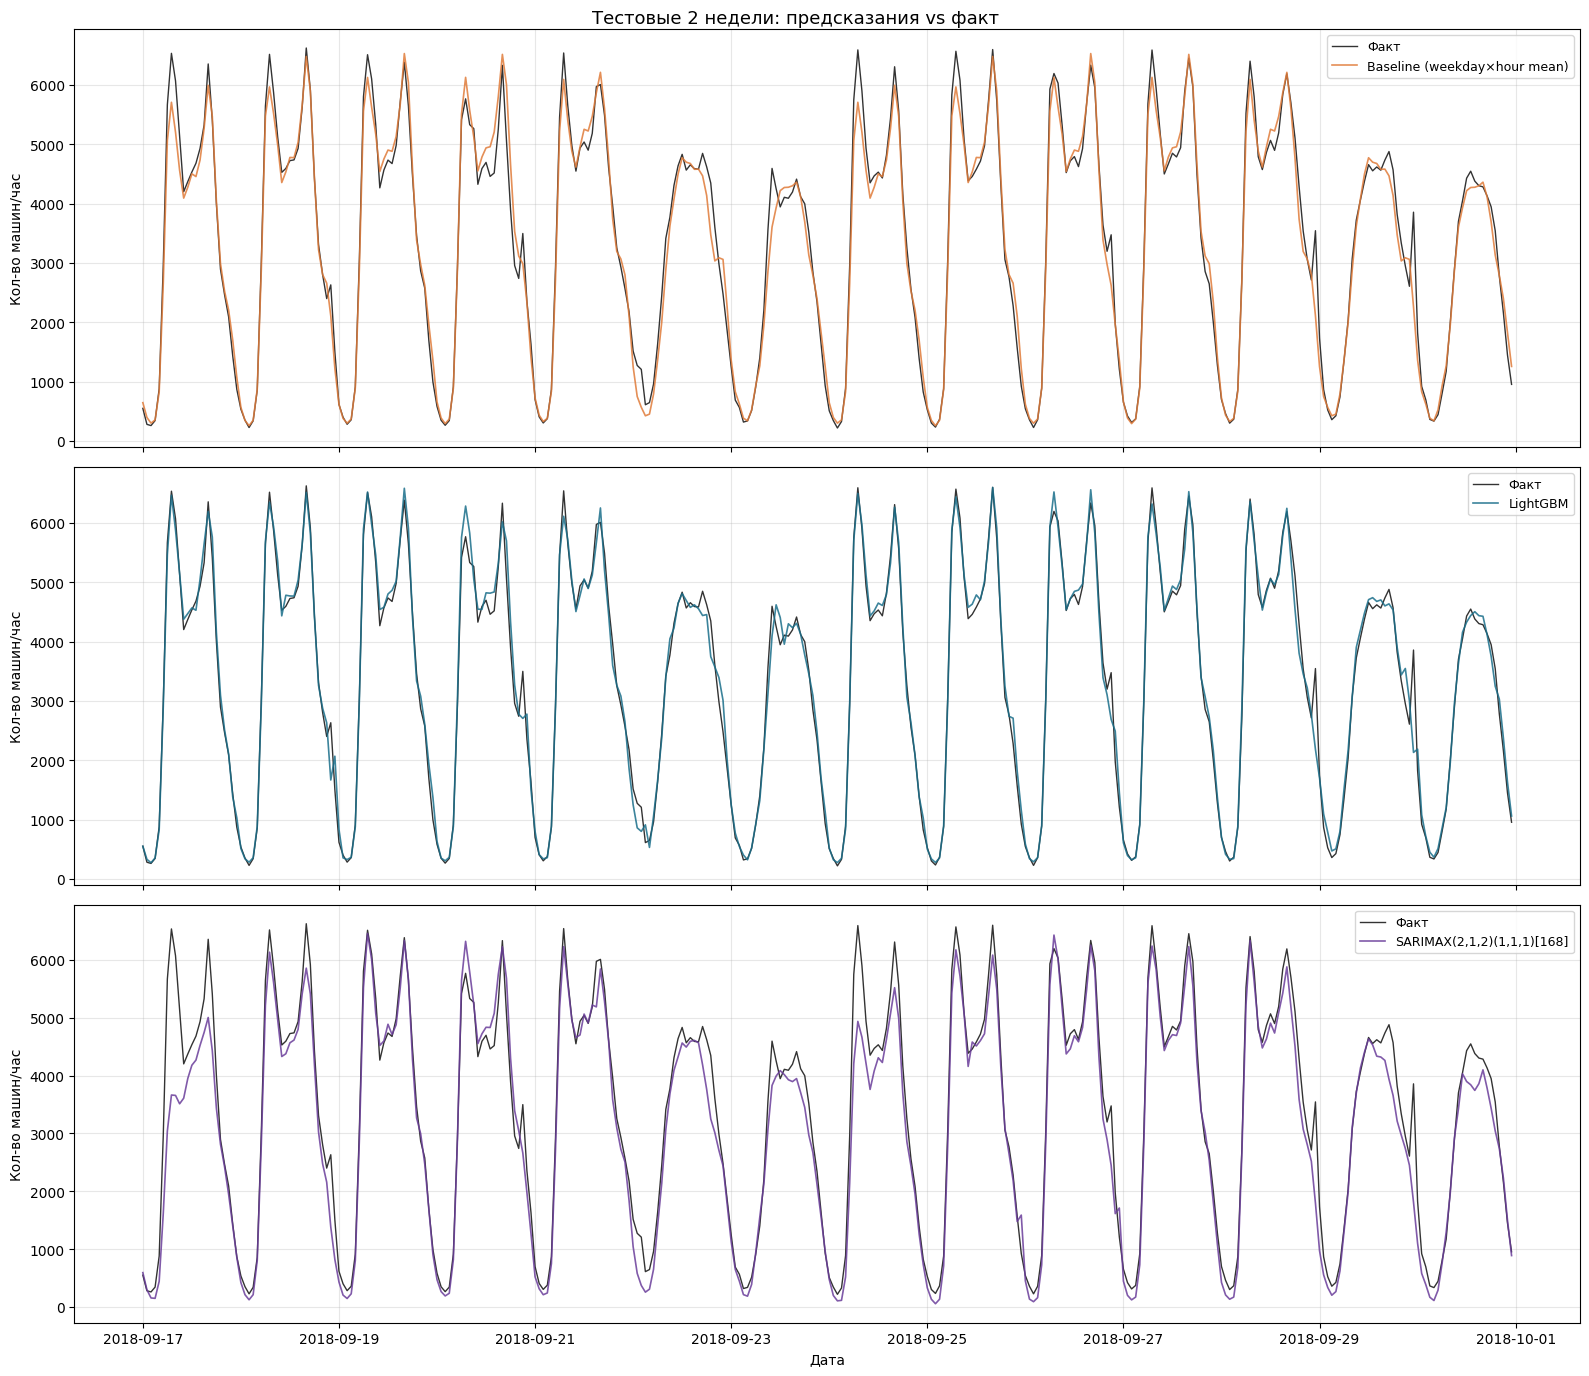

In [ ]:
# Таблица метрик
results_df = pd.DataFrame(results)
print('\n=== Сравнение моделей ===')
print(results_df.to_string(index=False))

# Совмещённый график: 3 панели (по одной на модель)
# sharex=True: оси X синхронизированы — удобно сравнивать
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, (col, label, color) in zip(axes, [
    ('pred_baseline', 'Baseline (weekday×hour mean)', '#e07b39'),
    ('pred_lgb',      'LightGBM',                    '#1a6e8a'),
    ('pred_sarima',   'SARIMAX(2,1,2)(1,1,1)[168]',  '#6a3d9a'),
]):
    ax.plot(test.index, test[TARGET], label='Факт', color='#333', lw=1)
    ax.plot(test.index, test[col],    label=label,  color=color,  lw=1.2, alpha=0.85)
    ax.set_ylabel('Кол-во машин/час')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Дата')
fig.suptitle('Тестовые 2 недели: предсказания vs факт', fontsize=13)
plt.tight_layout()

##### Выводы

Среди рассмотренных подходов наилучшее качество показала модель LightGBM с лагами, rolling-признаками и температурой. Она снизила ошибку относительно baseline по всем метрикам и лучше всего воспроизвела фактическую динамику трафика на тестовом интервале. SARIMAX с недельной сезонностью оказался значительно слабее, что говорит о недостаточности классической линейной сезонной модели для данного ряда.

## 10. Прогноз на неделю вперёд с 80%-м доверительным интервалом

### Почему квантильная регрессия
- Стандартный LightGBM (`objective='regression'`) предсказывает среднее значение —
нет никакой информации о неопределённости прогноза.

- Квантильная регрессия (`objective='quantile'`) минимизирует pinball loss:

$$L_q(y, \hat{y}) = \begin{cases} q \cdot (y - \hat{y}), & y \geq \hat{y} \\ (1-q) \cdot (\hat{y} - y), & y < \hat{y} \end{cases}$$

- При `alpha=0.1` модель предсказывает 10-й перцентиль (нижняя граница).
- При `alpha=0.9` — 90-й перцентиль (верхняя граница).
- Разница p90−p10 = 80%-й доверительный интервал.

### Рекурсивный прогноз
- Модель требует лаги `lag_1, lag_24, lag_168` — но будущие значения неизвестны.
- Решение: итерировать по одному шагу:
1. Предсказать `t+1`, используя известные данные
2. Добавить предсказание в буфер как «известный» `lag_1`
3. Предсказать `t+2`... и так 168 раз

- Ошибка накапливается — поэтому доверительный интервал расширяется к концу горизонта.

### Прокси для температуры
- Нужна температура для 168 будущих часов. 
- Берём значения из того же часа и дня недели ровно 364 дня назад (364 = 52 недели - тот же день недели).

Обучаем квантильные модели (q=0.10, 0.50, 0.90)...
Готово.
               p10          p50          p90
count   168.000000   168.000000   168.000000
mean   3263.138929  3417.886092  3575.500733
std    1923.878603  1986.713652  2000.697794
min     229.771871   251.745141   280.896695
25%    1366.710694  1446.859005  1786.112815
50%    3525.735026  3679.409837  3889.602458
75%    4806.939485  4973.397800  5129.883534
max    6365.955139  6605.826504  6709.035572


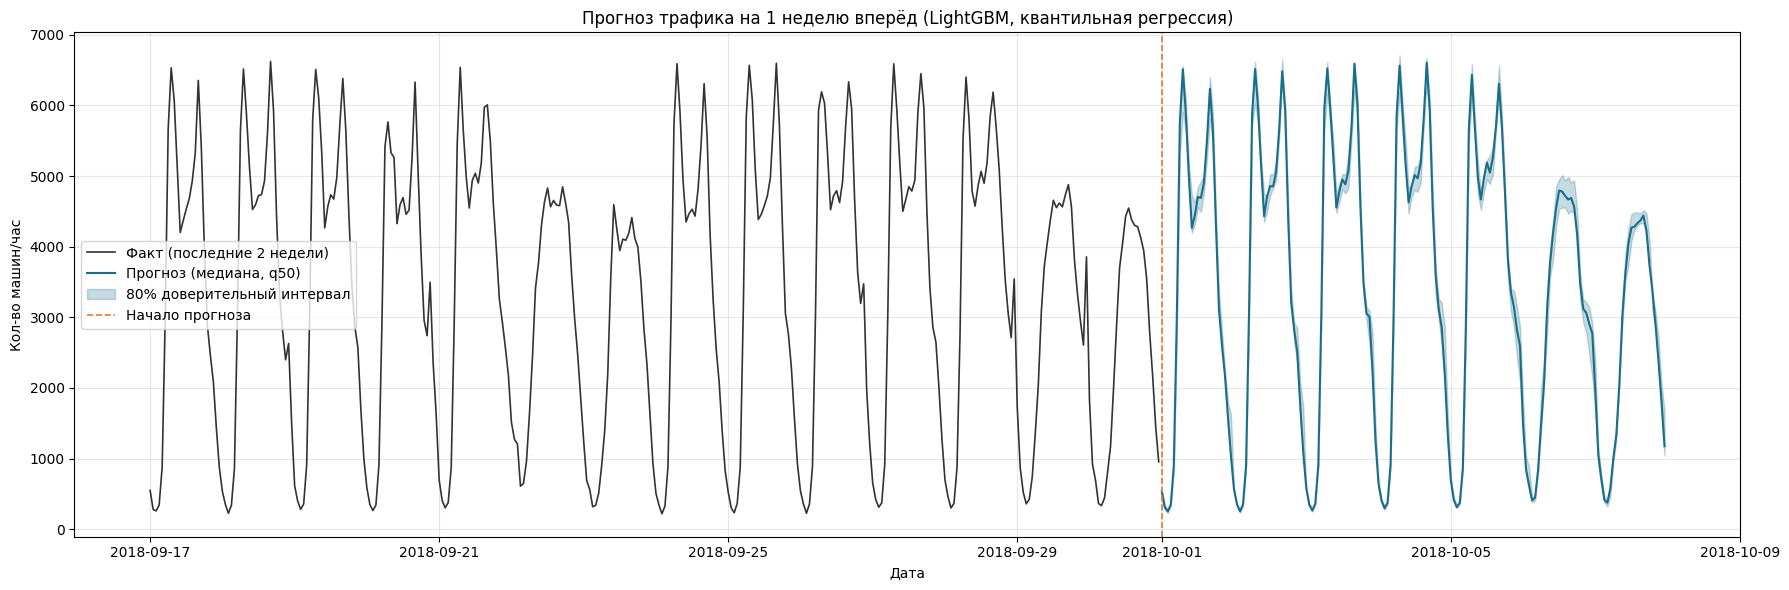

In [ ]:
# Обучаем три квантильные модели
def train_q(q):
    """Обучает LightGBM для квантиля q."""
    m = lgb.LGBMRegressor(
        objective='quantile',  # специальная задача квантильной регрессии
        alpha=q,               # целевой квантиль
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=63,
        n_jobs=-1,
        verbose=-1
    )
    m.fit(train[FEATURES], train[TARGET])
    return m

print('Обучаем квантильные модели (q=0.10, 0.50, 0.90)...')
qm10 = train_q(0.10)  # нижняя граница интервала (10-й перцентиль)
qm50 = train_q(0.50)  # медианный прогноз
qm90 = train_q(0.90)  # верхняя граница интервала (90-й перцентиль)
print('Готово.')

# Вспомогательная функция: признаки для одного будущего момента
def step_feat(buf, dt, temp=None):
    """Строит строку признаков для timestamp dt, используя буфер buf как историю."""
    r = {}
    r['hour']        = dt.hour
    r['weekday']     = dt.dayofweek
    r['month']       = dt.month
    r['is_weekend']  = int(dt.dayofweek >= 5)
    r['is_holiday']  = 0  # консервативно: не предполагаем праздников
    r['hour_sin']    = np.sin(2 * np.pi * r['hour'] / 24)
    r['hour_cos']    = np.cos(2 * np.pi * r['hour'] / 24)
    r['weekday_sin'] = np.sin(2 * np.pi * r['weekday'] / 7)
    r['weekday_cos'] = np.cos(2 * np.pi * r['weekday'] / 7)
    # Если temp не передан — fallback: среднее за последнюю неделю
    r['temp'] = temp if temp is not None else buf.iloc[-168:].mean()
    # Лаги из буфера (buf содержит все известные + предсказанные значения)
    for lag in [1, 2, 24, 48, 168]:
        r[f'lag_{lag}'] = buf.iloc[-lag] if len(buf) >= lag else np.nan
    r['roll_mean_24']  = buf.iloc[-24:].mean()
    r['roll_std_24']   = buf.iloc[-24:].std()
    r['roll_mean_168'] = buf.iloc[-168:].mean()
    return pd.DataFrame([r])

# Рекурсивный прогноз на 168 часов
# Горизонт прогноза: следующие 168 часов после последней точки в данных
future = pd.date_range(
    start=df.index[-1] + pd.Timedelta(hours=1),
    periods=168,
    freq='h'
)

p10, p50, p90 = [], [], []
buf = df['traffic_volume'].copy()  # буфер: начинаем с полного известного ряда

for ts in future:
    # Прокси для температуры: тот же час 364 дня назад (52 недели назад)
    ref = ts - pd.Timedelta(days=364)
    temp_v = df.loc[ref, 'temp'] if ref in df.index else buf.iloc[-168:].mean()

    # Строим признаковую строку и делаем три предсказания
    x = step_feat(buf, ts, temp_v)[FEATURES]
    v10 = max(0, qm10.predict(x).item())
    v50 = max(0, qm50.predict(x).item())
    v90 = max(0, qm90.predict(x).item())
    p10.append(v10); p50.append(v50); p90.append(v90)

    # Добавляем медианный прогноз в буфер для следующего шага
    # (используем p50 как лучшую оценку «реального» будущего значения)
    buf = pd.concat([buf, pd.Series([v50], index=[ts])])

fc = pd.DataFrame({'p10': p10, 'p50': p50, 'p90': p90}, index=future)
print(fc.describe().to_string())

# Финальный график
fig, ax = plt.subplots(figsize=(18, 6))

# Последние 2 недели реальных данных — контекст для прогноза
recent = df['traffic_volume'].iloc[-336:]
ax.plot(recent.index, recent.values,
        color='#333', lw=1.2, label='Факт (последние 2 недели)')

# Медианный прогноз на неделю вперёд
ax.plot(fc.index, fc['p50'],
        color='#1a6e8a', lw=1.5, label='Прогноз (медиана, q50)')

# Доверительный интервал 80%: заливка между p10 и p90
ax.fill_between(fc.index, fc['p10'], fc['p90'],
                alpha=0.25, color='#1a6e8a', label='80% доверительный интервал')

# Вертикальная линия = граница между известным и прогнозируемым
ax.axvline(fc.index[0], color='#e07b39', lw=1.2, ls='--', label='Начало прогноза')

ax.set_title('Прогноз трафика на 1 неделю вперёд (LightGBM, квантильная регрессия)')
ax.set_xlabel('Дата')
ax.set_ylabel('Кол-во машин/час')
ax.legend()
plt.tight_layout()

##### Выводы

Для финального прогноза на следующую неделю была использована квантильная версия LightGBM с уровнями 0.10, 0.50 и 0.90. Полученный медианный прогноз сохраняет недельную и суточную сезонность ряда, а доверительный интервал адекватно отражает неопределённость и расширяется в периоды повышенной изменчивости.